In [1]:
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,BatchNormalization,Dropout, LeakyReLU,Conv2D,MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
# Flatten the label arrays
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Define selected class labels (airplane=0, automobile=1, bird=2, cat=3)
selected_classes = [0, 1, 2, 3,4,5,6,7]

# Create boolean masks to select only the desired classes
train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

# Apply the masks to filter images and labels
X_train_filtered = X_train[train_mask]
y_train_filtered = y_train[train_mask]
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]

# Normalize the image pixel values to [0, 1]
X_train_filtered = X_train_filtered / 255.0
X_test_filtered = X_test_filtered / 255.0

# One-hot encode the labels with num_classes=4 (since we have 8 classes)
y_train_oh = to_categorical(y_train_filtered, num_classes=8)
y_test_oh = to_categorical(y_test_filtered, num_classes=8)

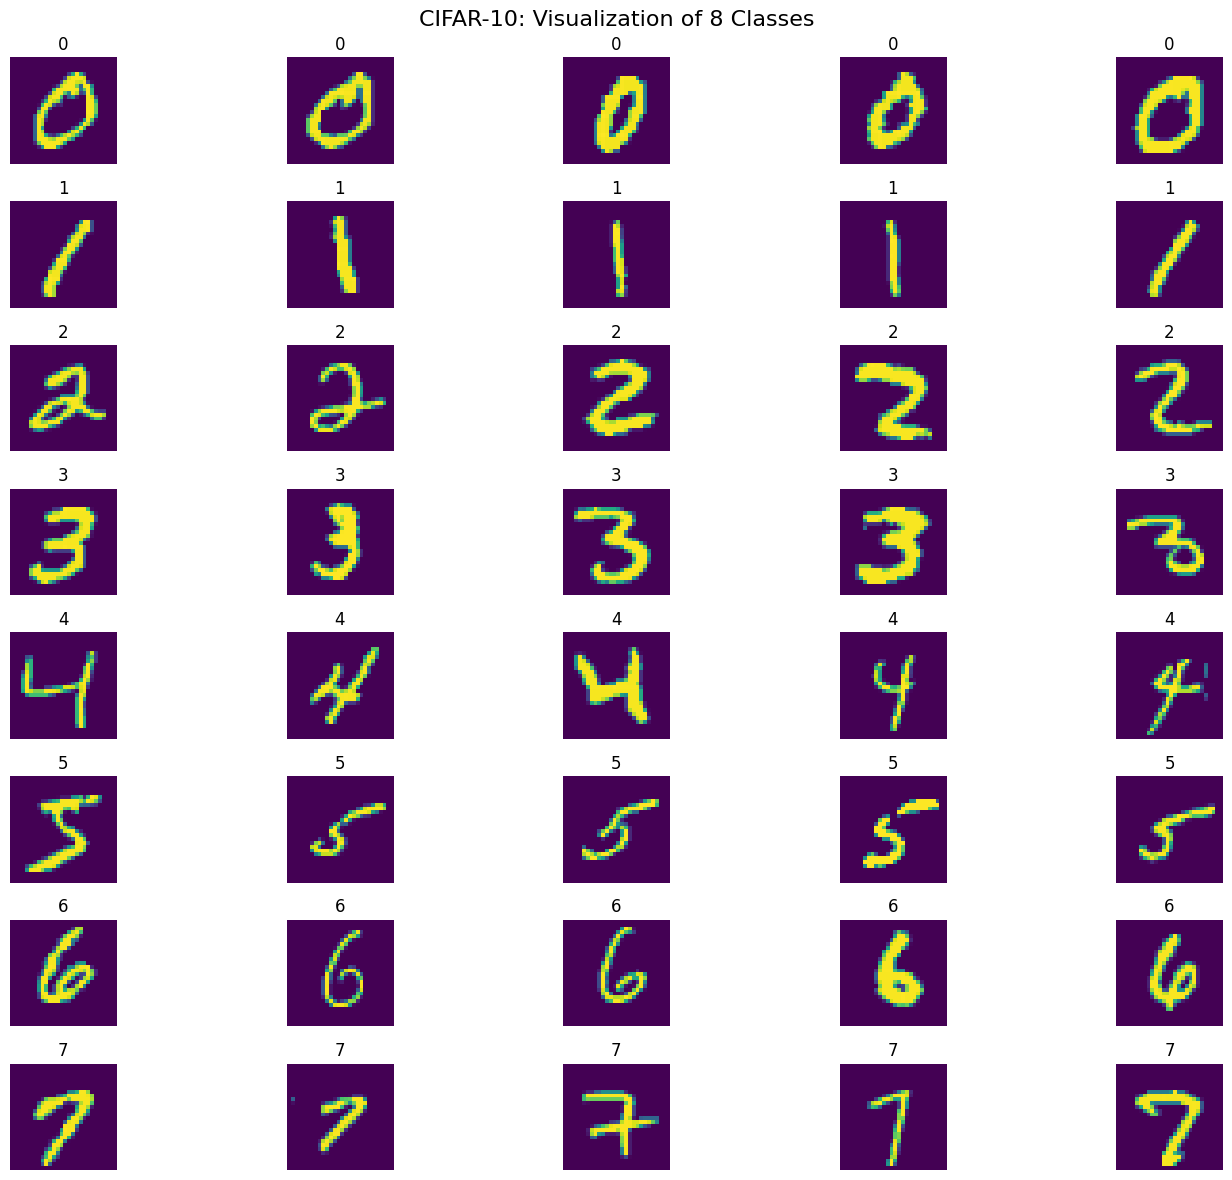

In [4]:
# Class names for 8 selected CIFAR-10 classes
class_names = ['0','1','2','3','4','5','6','7']
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7]  # Corresponding class indices

plt.figure(figsize=(15, 12))

# Plot 5 images for each of the 8 selected classes
for class_index, class_label in enumerate(selected_classes):
    # Get indices of training images for this class
    indices = np.where(y_train_filtered == class_label)[0]
    # Plot 5 sample images for the class
    for i in range(5):
        plt.subplot(8, 5, class_index * 5 + i + 1)
        plt.imshow(X_train_filtered[indices[i]])
        plt.title(class_names[class_index])
        plt.axis('off')

plt.suptitle("CIFAR-10: Visualization of 8 Classes", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(8, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905,224 (3.45 MB)

 Trainable params: 905,224 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer = 'adam',loss = 'categorical_crossentropy',metrics = ['accuracy'])

In [8]:
history =model.fit(X_train_filtered, y_train_oh, epochs=3,validation_data=(X_test_filtered,y_test_oh), batch_size=64)

Epoch 1/3
754/754 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9253 - loss: 0.2485 - val_accuracy: 0.9911 - val_loss: 0.0274
Epoch 2/3
754/754 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 3/3
754/754 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9928 - val_loss: 0.0227


In [9]:
model.evaluate(X_test_filtered, y_test_oh)


251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0293


[0.022703252732753754, 0.9927653670310974]

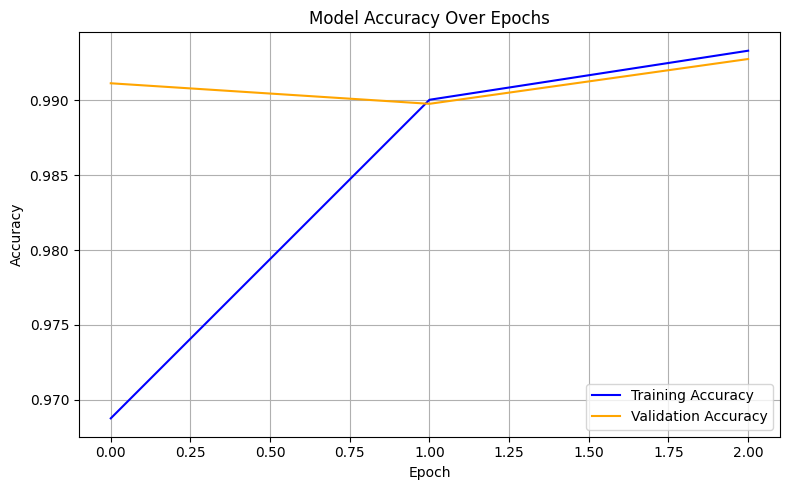

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


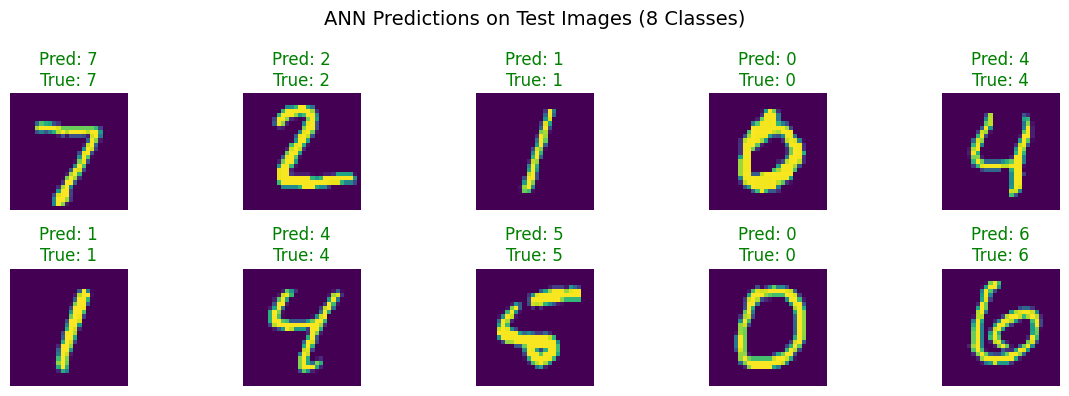

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Predict on first 10 test images
pred_probs = model.predict(X_test_filtered[:10])
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(y_test_oh[:10], axis=1)

# Class labels for 8 selected classes
class_names = ['0','1','2','3','4','5','6','7']

# Plot predictions with color-coded titles
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_filtered[i])
    plt.title(f"Pred: {class_names[pred_classes[i]]}\nTrue: {class_names[true_classes[i]]}",
              color="green" if pred_classes[i] == true_classes[i] else "red")
    plt.axis('off')

plt.suptitle("ANN Predictions on Test Images (8 Classes)", fontsize=14)
plt.tight_layout()
plt.show()
